# Mental Health in Technology-related Jobs

**Course:** Machine Learning – Unsupervised Learning and Feature Engineering

This notebook explores the 2016 Mental Health in Tech Survey. It prepares the survey data, applies K-Means clustering, compares different values of K, and summarizes the resulting clusters.


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)


## 2. Load and explore the dataset

The CSV path below assumes that the notebook is in the `notebooks` folder and the dataset is in the `data` folder next to it.


In [2]:
df = pd.read_csv("Task-1 Mental-Health/data/mental-heath-in-tech-2016_20161114.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1433, 63)


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1146 non-null   str    
 2   Is your employer primarily a tech company/organization?                

In [4]:
df.describe()


,Are you self-employed?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you have previous employers?,Have you ever sought treatment for a mental health issue from a mental health professional?,What is your age?
count,1433.000000,1146.000000,263.000000,287.000000,1433.000000,1433.000000,1433.000000
mean,0.200279,0.770506,0.942966,0.644599,0.882066,0.585485,34.286113
std,0.400349,0.420691,0.232350,0.479471,0.322643,0.492810,11.290931
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,28.000000
50%,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,33.000000
75%,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,39.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,323.000000


In [5]:
df.isnull().sum().sort_values(ascending=False)


If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?            1289
If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?    1229
Is your primary role within your company related to tech/IT?                                                                            1170
Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?                   1146
If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?            1146
                                                                                                                                        ... 
What is your age?                                                                                                                          0
What country 

In [6]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [7]:
df["What is your age?"].describe()


count    1433.000000
mean       34.286113
std        11.290931
min         3.000000
25%        28.000000
50%        33.000000
75%        39.000000
max       323.000000
Name: What is your age?, dtype: float64

In [8]:
df["What is your gender?"].value_counts(dropna=False)


What is your gender?
Male                                       610
male                                       249
Female                                     153
female                                      95
M                                           86
                                          ... 
female-bodied; no feelings about gender      1
cis man                                      1
AFAB                                         1
Transgender woman                            1
MALE                                         1
Name: count, Length: 71, dtype: int64

In [9]:
df["Are you self-employed?"].value_counts(dropna=False)


Are you self-employed?
0    1146
1     287
Name: count, dtype: int64

## 3. Clean the data

In [10]:
df_clean = df.copy()


### 3.1 Clean age values

I removed the four age values that I identified as unrealistic during data exploration, while keeping the other less common ages because they were still possible.



In [11]:
invalid_ages = [3, 15, 99, 323]

df_clean = df_clean[
    ~df_clean["What is your age?"].isin(invalid_ages)
].copy()

print("Shape after age cleaning:", df_clean.shape)


Shape after age cleaning: (1429, 63)


### 3.2 Standardize gender responses

The survey had different spellings and ways of describing gender, so I grouped similar responses into broader categories to make the data easier to analyze.



In [12]:
def clean_gender(gender):
    if pd.isna(gender):
        return "Unknown"

    gender = str(gender).strip().lower()

    male = [
        "male", "m", "man", "cis male", "cis man", "male.",
        "male (cis)", "mail", "malr", "sex is male",
        "cisdude", "dude", "m|", "male "
    ]

    female = [
        "female", "f", "woman", "cis female", "cis-woman",
        "female ", "i identify as female.", "female/woman",
        "fem", "fm", "female assigned at birth "
    ]

    other = [
        "agender", "androgynous", "bigender", "enby",
        "genderfluid", "genderfluid (born female)",
        "genderflux demi-girl", "genderqueer",
        "genderqueer woman", "fluid", "nonbinary",
        "non-binary", "other/transfeminine", "queer",
        "transgender woman", "transitioned, m2f", "mtf",
        "nb masculine", "female or multi-gender femme",
        "male (trans, ftm)", "male/genderqueer", "afab"
    ]

    if gender in male:
        return "Male"
    elif gender in female:
        return "Female"
    elif gender in other:
        return "Other"
    else:
        return "Other"


df_clean["What is your gender?"] = (
    df_clean["What is your gender?"].apply(clean_gender)
)

df_clean["What is your gender?"].value_counts()


What is your gender?
Male       1053
Female      335
Other        38
Unknown       3
Name: count, dtype: int64

### 3.3 Remove columns not used in the analysis

I removed the free-text diagnosis and reason fields, along with some location and work-related columns that were not needed for this clustering analysis.



In [13]:
columns_to_drop = [
    "Why or why not?",
    "Why or why not?.1",
    "If yes, what condition(s) have you been diagnosed with?",
    "If maybe, what condition(s) do you believe you have?",
    "If so, what condition(s) were you diagnosed with?",
    "What country do you live in?",
    "What US state or territory do you live in?",
    "What country do you work in?",
    "What US state or territory do you work in?",
    "Which of the following best describes your work position?",
    "If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?",
    "If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",
    "Is your primary role within your company related to tech/IT?",
    "If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?",
    "Do you know local or online resources to seek help for a mental health disorder?",
    "If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?",
    "Do you believe your productivity is ever affected by a mental health issue?",
    "If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?"
]

df_clean = df_clean.drop(columns=columns_to_drop)
print("Shape after dropping selected columns:", df_clean.shape)


Shape after dropping selected columns: (1429, 45)


In [14]:
df_clean = df_clean.fillna("Not Applicable")

print("Remaining missing values:", df_clean.isnull().sum().sum())


Remaining missing values: 0


### 3.4 Handle missing values

In this notebook, I replaced missing responses with `Not Applicable` before encoding. This allowed me to keep all the rows, while treating missing responses as a separate category during the analysis.



In [15]:
df_clean.to_csv("mental_health_clean_day2.csv", index=False)


## 4. Feature engineering

### 4.1 One-Hot Encoding

I converted the categorical responses into separate indicator columns so that K-Means could use them for clustering.


In [16]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)

bool_columns = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

print("Encoded dataset shape:", df_encoded.shape)
df_encoded.info()


Encoded dataset shape: (1429, 137)
<class 'pandas.DataFrame'>
Index: 1429 entries, 0 to 1432
Columns: 137 entries, Are you self-employed? to Do you work remotely?_Sometimes
dtypes: int64(137)
memory usage: 1.5 MB


In [17]:
df_encoded.to_csv("mental_health_preprocessed.csv", index=False)


## 5. Scale the features

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (1429, 137)


## 6. Choose the number of clusters

I tested K values from 2 to 10. The Elbow Method looks at the within-cluster sum of squares (inertia), while the Silhouette Score shows how well each observation fits its own cluster compared with the other clusters.


In [19]:
k_values = range(2, 11)
inertia = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))


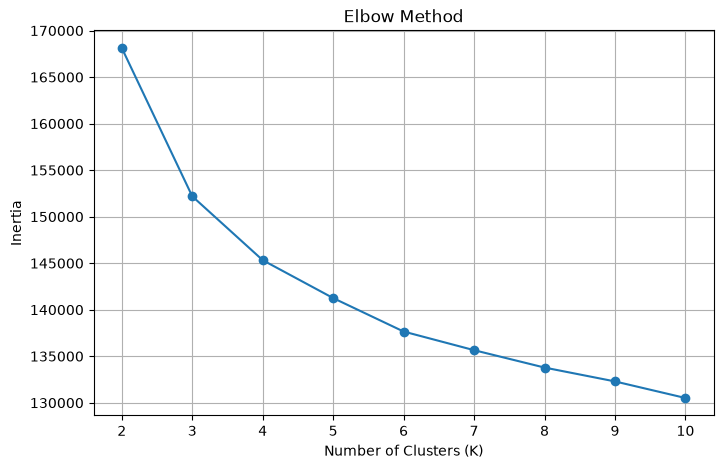

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()


In [21]:
for k, score in zip(k_values, silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")


K = 2: Silhouette Score = 0.1672
K = 3: Silhouette Score = 0.1805
K = 4: Silhouette Score = 0.1135
K = 5: Silhouette Score = 0.1113
K = 6: Silhouette Score = 0.1097
K = 7: Silhouette Score = 0.0995
K = 8: Silhouette Score = 0.0930
K = 9: Silhouette Score = 0.0956
K = 10: Silhouette Score = 0.0684


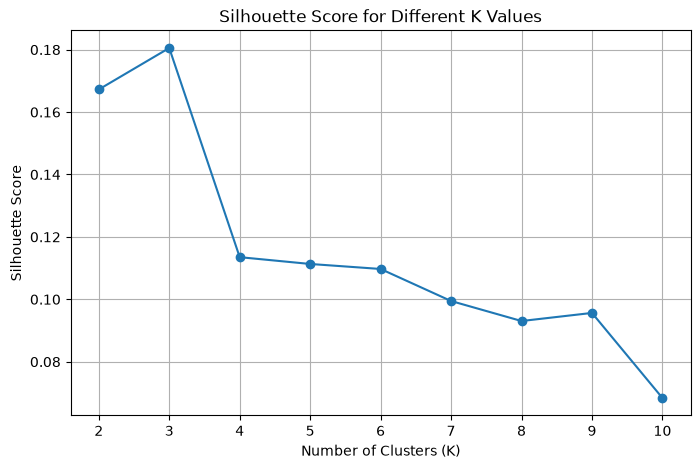

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.grid(True)
plt.show()


## 7. Fit the final K-Means model

I selected K = 3 because it had the highest Silhouette Score among the K values I tested.


In [23]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

## 8. PCA calculation & visualization

PCA was applied to reduce the 137 standardized features to two principal components for visualization. The K-Means clustering was performed separately using all 137 standardized features


In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance by PC1:", explained_variance[0])
print("Explained variance by PC2:", explained_variance[1])
print("Total explained variance:", explained_variance.sum())

Explained variance by PC1: 0.14238699174461383
Explained variance by PC2: 0.10084715608916568
Total explained variance: 0.2432341478337795


In [25]:
df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

df_pca["Cluster"] = labels

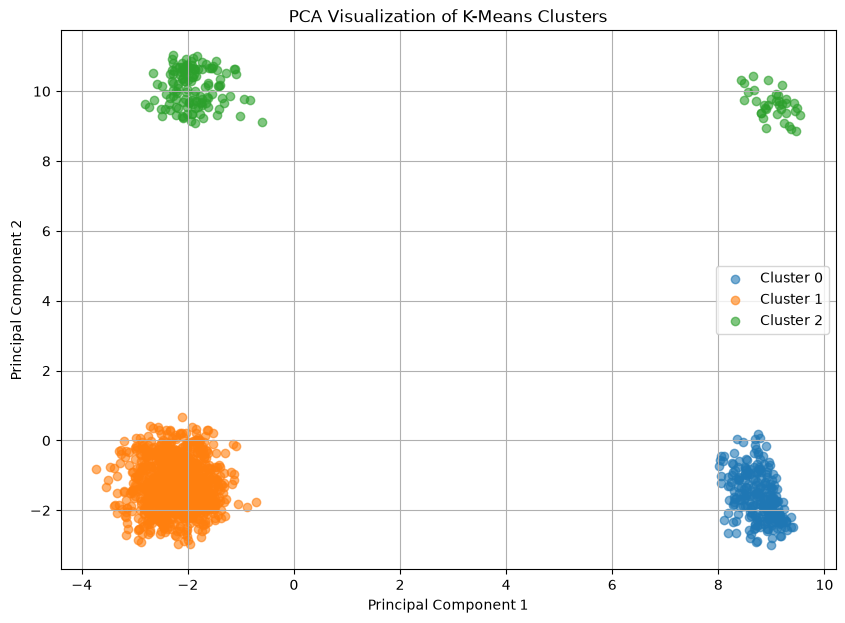

In [32]:
plt.figure(figsize=(10, 7))

for cluster in sorted(df_pca["Cluster"].unique()):
    cluster_data = df_pca[df_pca["Cluster"] == cluster]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of K-Means Clusters")
plt.legend()
plt.grid(True)
plt.show()

## 9. Review the clusters

In [29]:
df_clustered = df_encoded.copy()
df_clustered["Cluster"] = labels

cluster_counts = df_clustered["Cluster"].value_counts().sort_index()
cluster_percent = (
    df_clustered["Cluster"].value_counts(normalize=True).sort_index() * 100
).round(2)

print("Number of respondents in each cluster:")
display(cluster_counts)

print("Percentage in each cluster:")
display(cluster_percent)


Number of respondents in each cluster:


Cluster
0     249
1    1012
2     168
Name: count, dtype: int64

Percentage in each cluster:


Cluster
0    17.42
1    70.82
2    11.76
Name: proportion, dtype: float64

In [30]:
cluster_summary = df_clustered.groupby("Cluster").mean()

important_columns = [
    "Have you ever sought treatment for a mental health issue from a mental health professional?",
    "What is your age?",
    "Are you self-employed?",
    "Do you work remotely?_Never",
    "Do you work remotely?_Sometimes",
    "What is your gender?_Male",
    "What is your gender?_Other",
    "What is your gender?_Unknown"
]

available_columns = [
    column for column in important_columns
    if column in cluster_summary.columns
]

cluster_summary[available_columns]


,Have you ever sought treatment for a mental health issue from a mental health professional?,What is your age?,Are you self-employed?,Do you work remotely?_Never,Do you work remotely?_Sometimes,What is your gender?_Male,What is your gender?_Other,What is your gender?_Unknown
Cluster,,,,,,,,
0,0.646586,37.277108,1.000000,0.056225,0.485944,0.718876,0.020080,0.000000
1,0.588933,33.819170,0.000000,0.258893,0.533597,0.735178,0.025692,0.002964
2,0.476190,30.863095,0.220238,0.339286,0.547619,0.773810,0.041667,0.000000


## 10. Save the results

In [31]:
df_clustered.to_csv("mental_health_clustered.csv", index=False)
cluster_summary[available_columns].to_csv("cluster_summary.csv")

print("Saved the clustered dataset and cluster summary.")


Saved the clustered dataset and cluster summary.
